# 01 - Data, EDA và Feature Engineering cho đồ án Solar Forecasting

Notebook này là bước khởi đầu. Mục tiêu: đọc dữ liệu NASA POWER hourly, tạo target rõ ràng, EDA, tạo feature chống leakage và split train/validation/test theo thời gian.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path('morocco_data.csv')
FIG_DIR = Path('figures')
OUT_DIR = Path('outputs')
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
print('Ready!')

Ready!


## 1. Đọc dữ liệu NASA POWER và tạo datetime index
File có header metadata 14 dòng đầu, do đó dùng `skiprows=14`.

In [2]:
raw = pd.read_csv(DATA_PATH, skiprows=14)
raw['datetime'] = pd.to_datetime(dict(
    year=raw['YEAR'], month=raw['MO'], day=raw['DY'], hour=raw['HR']
))
raw = raw.set_index('datetime').sort_index()

rename_cols = {
    'PS': 'Pressure',
    'WS10M': 'Wind_Speed',
    'WD10M': 'Wind_Direction',
    'RH2M': 'Humidity',
    'ALLSKY_SFC_SW_DWN': 'Solar_Radiation_Wh_m2',
    'T2M': 'Temperature'
}
df = raw.rename(columns=rename_cols)
df = df.replace(-999, np.nan)

print('Shape:', df.shape)
print('Date range:', df.index.min(), '→', df.index.max())
print('Columns:', df.columns.tolist())
display(df.head())
display(df.isna().sum())

Shape: (26304, 10)
Date range: 2016-01-01 00:00:00 → 2018-12-31 23:00:00
Columns: ['YEAR', 'MO', 'DY', 'HR', 'Pressure', 'Wind_Speed', 'Wind_Direction', 'Humidity', 'Solar_Radiation_Wh_m2', 'Temperature']


,YEAR,MO,DY,HR,Pressure,Wind_Speed,Wind_Direction,Humidity,Solar_Radiation_Wh_m2,Temperature
datetime,,,,,,,,,,
2016-01-01 00:00:00,2016,1,1,0,87.96,1.63,235.5,36.48,0.0,8.09
2016-01-01 01:00:00,2016,1,1,1,87.92,1.49,233.7,36.86,0.0,7.88
2016-01-01 02:00:00,2016,1,1,2,87.88,1.41,232.8,37.25,0.0,7.72
2016-01-01 03:00:00,2016,1,1,3,87.85,1.43,232.1,38.24,0.0,7.33
2016-01-01 04:00:00,2016,1,1,4,87.85,1.48,234.4,39.91,0.0,6.76


YEAR                     0
MO                       0
DY                       0
HR                       0
Pressure                 0
Wind_Speed               0
Wind_Direction           0
Humidity                 0
Solar_Radiation_Wh_m2    0
Temperature              0
dtype: int64

## 2. Tạo target chính
`ALLSKY_SFC_SW_DWN` là bức xạ ngắn sóng bề mặt theo giờ, đơn vị Wh/m². Để quy đổi sang kJ/m²: `1 Wh = 3.6 kJ`.

In [3]:
df['Solar_Energy_kJ_m2'] = df['Solar_Radiation_Wh_m2'] * 3.6

numeric_cols = ['Pressure', 'Wind_Speed', 'Wind_Direction', 'Humidity',
                'Solar_Radiation_Wh_m2', 'Temperature', 'Solar_Energy_kJ_m2']
df[numeric_cols] = df[numeric_cols].interpolate('time').ffill().bfill()

freq_check = df.index.to_series().diff().value_counts().head()
print('Frequency check:')
print(freq_check)

display(df[numeric_cols].describe().T)

Frequency check:
datetime
0 days 01:00:00    26303
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Pressure,26304.0,87.256612,0.469241,85.59,86.970,87.300,87.550,88.67
Wind_Speed,26304.0,3.627501,2.238075,0.02,2.020,3.080,4.810,15.31
Wind_Direction,26304.0,191.231908,113.448134,0.00,98.475,196.000,301.500,359.90
Humidity,26304.0,41.737428,22.749388,3.23,22.740,38.480,57.840,100.00
Solar_Radiation_Wh_m2,26304.0,245.812584,324.709271,0.00,0.000,10.705,502.755,1087.40
Temperature,26304.0,17.300136,9.913768,-5.28,9.240,17.050,24.490,40.61
Solar_Energy_kJ_m2,26304.0,884.925304,1168.953375,0.00,0.000,38.538,1809.918,3914.64


## 3. EDA: xu hướng thời gian, chu kỳ ngày và chu kỳ tháng
Các hình này dùng trực tiếp trong báo cáo.

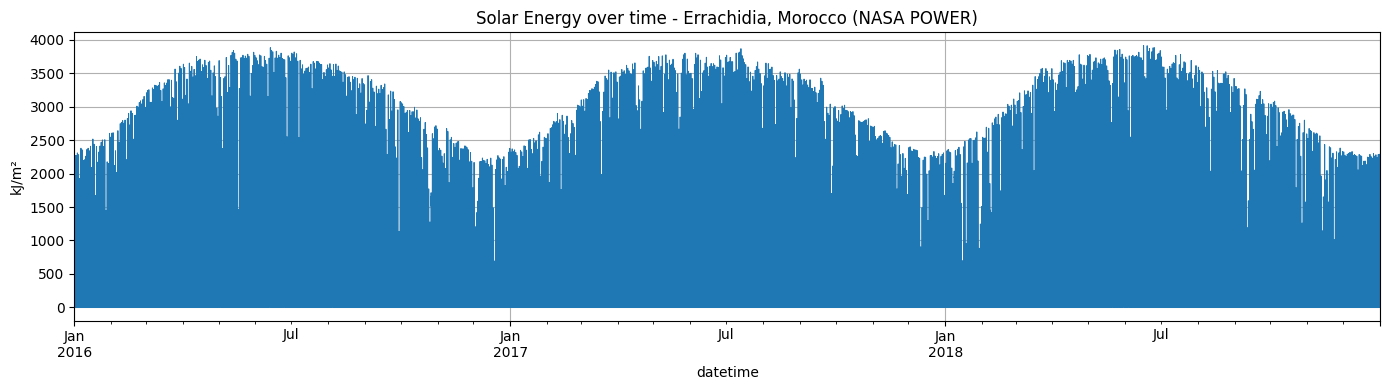

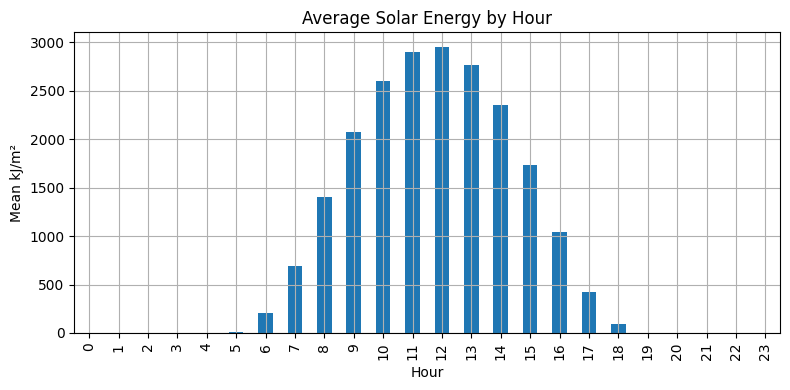

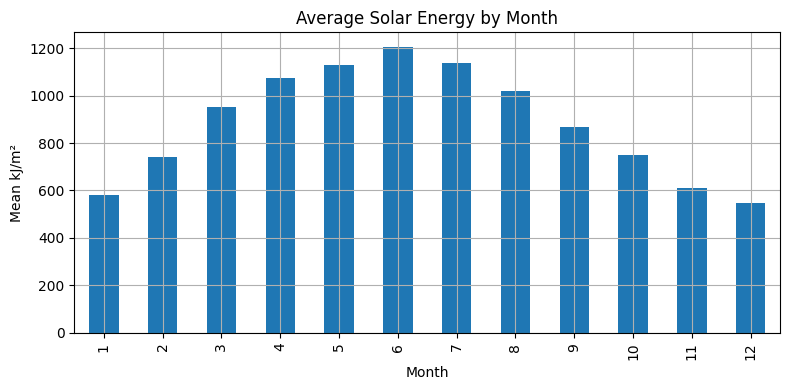

In [4]:
plt.figure(figsize=(14,4))
df['Solar_Energy_kJ_m2'].plot(linewidth=0.7)
plt.title('Solar Energy over time - Errachidia, Morocco (NASA POWER)')
plt.ylabel('kJ/m²')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_solar_energy_timeseries.png', dpi=200)
plt.show()

hourly_mean = df.groupby(df.index.hour)['Solar_Energy_kJ_m2'].mean()
plt.figure(figsize=(8,4))
hourly_mean.plot(kind='bar')
plt.title('Average Solar Energy by Hour')
plt.xlabel('Hour')
plt.ylabel('Mean kJ/m²')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_avg_by_hour.png', dpi=200)
plt.show()

monthly_mean = df.groupby(df.index.month)['Solar_Energy_kJ_m2'].mean()
plt.figure(figsize=(8,4))
monthly_mean.plot(kind='bar')
plt.title('Average Solar Energy by Month')
plt.xlabel('Month')
plt.ylabel('Mean kJ/m²')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_avg_by_month.png', dpi=200)
plt.show()

In [5]:
# Daylight-only overview
night_ratio = (df['Solar_Energy_kJ_m2'] <= 0).mean()
print(f'Tỷ lệ giờ có Solar_Energy = 0: {night_ratio:.2%}')

day_df = df[df['Solar_Energy_kJ_m2'] > 0]
print('All-hours rows:', len(df))
print('Daylight rows:', len(day_df))

display(day_df['Solar_Energy_kJ_m2'].describe())

Tỷ lệ giờ có Solar_Energy = 0: 48.22%
All-hours rows: 26304
Daylight rows: 13620


count    13620.000000
mean      1709.036358
std       1109.302620
min          6.300000
25%        694.557000
50%       1736.640000
75%       2622.519000
max       3914.640000
Name: Solar_Energy_kJ_m2, dtype: float64

## 4. Pearson correlation
Dùng để liên hệ với bài báo gốc, nhưng không dùng Pearson như tiêu chí duy nhất trong pipeline cải tiến.

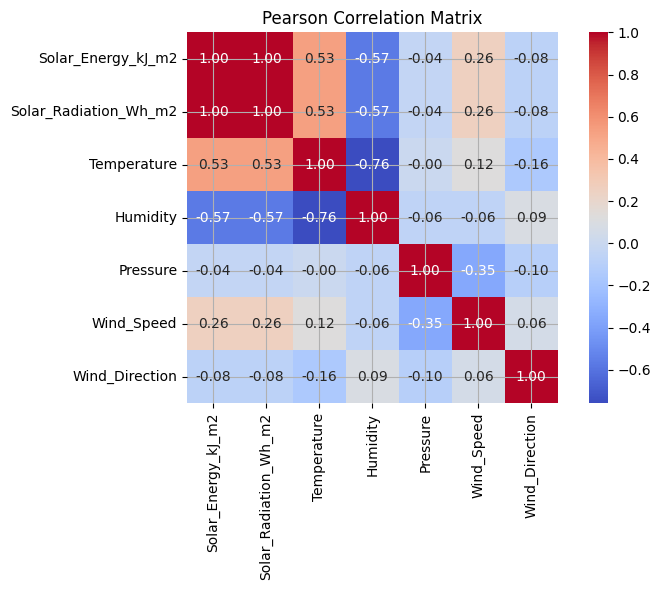

In [6]:
corr_cols = ['Solar_Energy_kJ_m2', 'Solar_Radiation_Wh_m2', 'Temperature',
             'Humidity', 'Pressure', 'Wind_Speed', 'Wind_Direction']

plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_pearson_heatmap.png', dpi=200)
plt.show()

## 5. Tạo feature chu kỳ, lag và rolling
Rolling feature phải dùng `shift(1)` trước khi rolling để tránh leakage.

In [7]:
def add_time_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    hour = out.index.hour
    doy = out.index.dayofyear
    month = out.index.month
    out['hour_sin'] = np.sin(2*np.pi*hour/24)
    out['hour_cos'] = np.cos(2*np.pi*hour/24)
    out['doy_sin'] = np.sin(2*np.pi*doy/365.25)
    out['doy_cos'] = np.cos(2*np.pi*doy/365.25)
    out['month_sin'] = np.sin(2*np.pi*month/12)
    out['month_cos'] = np.cos(2*np.pi*month/12)
    out['is_daytime_by_hour'] = ((hour >= 6) & (hour <= 19)).astype(int)
    return out


def add_lag_rolling_features(data: pd.DataFrame, target: str = 'Solar_Energy_kJ_m2') -> pd.DataFrame:
    out = data.copy()
    target_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
    for lag in target_lags:
        out[f'{target}_lag_{lag}h'] = out[target].shift(lag)

    shifted = out[target].shift(1)
    for w in [3, 6, 24, 72, 168]:
        out[f'{target}_roll_mean_{w}h'] = shifted.rolling(w).mean()
        out[f'{target}_roll_std_{w}h'] = shifted.rolling(w).std()
        out[f'{target}_roll_max_{w}h'] = shifted.rolling(w).max()
        out[f'{target}_roll_min_{w}h'] = shifted.rolling(w).min()

    for col in ['Temperature', 'Humidity', 'Pressure', 'Wind_Speed']:
        for lag in [1, 3, 24]:
            out[f'{col}_lag_{lag}h'] = out[col].shift(lag)
    return out

feat_df = add_time_features(df)
feat_df = add_lag_rolling_features(feat_df)

# Targets: dự báo 1 giờ và 24 giờ sau
feat_df['target_1h'] = feat_df['Solar_Energy_kJ_m2'].shift(-1)
feat_df['target_24h'] = feat_df['Solar_Energy_kJ_m2'].shift(-24)
feat_df = feat_df.dropna()

print('Feature dataframe shape:', feat_df.shape)
display(feat_df.head())

Feature dataframe shape: (26112, 61)


,YEAR,MO,DY,HR,Pressure,Wind_Speed,Wind_Direction,Humidity,Solar_Radiation_Wh_m2,Temperature,...,Humidity_lag_3h,Humidity_lag_24h,Pressure_lag_1h,Pressure_lag_3h,Pressure_lag_24h,Wind_Speed_lag_1h,Wind_Speed_lag_3h,Wind_Speed_lag_24h,target_1h,target_24h
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-08 00:00:00,2016,1,8,0,87.56,2.72,231.9,68.70,0.0,4.80,...,66.93,41.22,87.61,87.70,87.73,2.85,2.91,2.38,0.0,0.0
2016-01-08 01:00:00,2016,1,8,1,87.51,2.61,232.8,68.13,0.0,4.81,...,68.90,42.19,87.56,87.66,87.67,2.72,2.89,2.21,0.0,0.0
2016-01-08 02:00:00,2016,1,8,2,87.47,2.52,233.4,67.86,0.0,4.72,...,69.39,43.69,87.51,87.61,87.62,2.61,2.85,2.15,0.0,0.0
2016-01-08 03:00:00,2016,1,8,3,87.46,2.56,222.5,68.53,0.0,4.51,...,68.70,45.08,87.47,87.56,87.59,2.52,2.72,2.09,0.0,0.0
2016-01-08 04:00:00,2016,1,8,4,87.45,2.53,224.7,69.56,0.0,4.40,...,68.13,46.33,87.46,87.51,87.60,2.56,2.61,2.01,0.0,0.0


## 5B. Advanced features: daylight, clear-sky proxy và simulated PV output

Cell này tạo các biến nâng cao cần thiết.

Các nhóm biến được tạo:

- **Solar geometry / daylight:** `solar_elevation_approx_deg`, `sun_up_by_geometry`, `is_daylight_geometry`.
- **Clear-sky proxy:** `clear_sky_ghi_proxy_Wh_m2`, `clear_sky_index_current`.
- **Optional pvlib features:** nếu máy đã cài `pvlib`, notebook sẽ tự tạo thêm `pvlib_solar_elevation_deg`, `pvlib_clear_sky_ghi_Wh_m2`, `pvlib_clear_sky_index_current`. Nếu chưa cài, notebook tự bỏ qua và vẫn chạy bình thường.
- **Simulated PV output:** `sim_cell_temperature_C`, `sim_pv_dc_kWh_per_kWp`, `sim_pv_ac_kWh_per_kWp` và các lag của PV mô phỏng.

Lưu ý phương pháp:

- `clear_sky_ghi_proxy_Wh_m2` là xấp xỉ hình học đơn giản, dùng để tăng thông tin vật lý cho mô hình, không phải clear-sky model đầy đủ.
- Nếu dùng `pvlib`, các biến `pvlib_*` đáng tin cậy hơn proxy vì pvlib tính solar position và clear-sky irradiance theo mô hình chuẩn hơn.
- `clear_sky_index_current = Solar_Radiation hiện tại / clear_sky hiện tại`; biến này dùng được cho bài toán dự báo `t+1` vì chỉ dùng thông tin tại thời điểm `t`.
- `sim_pv_*` là **simulated PV energy**, không phải sản lượng đo thực tế của nhà máy điện mặt trời.


In [8]:

# ============================================================
# 5B. ADVANCED FEATURES: CLEAR-SKY AND SIMULATED PV OUTPUT
# ============================================================

LATITUDE = 31.93       # Errachidia, Morocco - from NASA POWER header
LONGITUDE = -4.42      # Errachidia, Morocco - from NASA POWER header
ALTITUDE_M = 1307.6    # from NASA POWER header
TIMEZONE_FOR_PVLIB = 'UTC'  


def add_solar_geometry_and_clearsky_proxy(data: pd.DataFrame,
                                          lat: float = LATITUDE,
                                          lon: float = LONGITUDE) -> pd.DataFrame:
    """
    Tạo các đặc trưng hình học mặt trời và clear-sky proxy không phụ thuộc pvlib.

    Đây là xấp xỉ vật lý đơn giản:
    - solar_elevation_approx_deg: góc cao mặt trời xấp xỉ theo ngày trong năm và giờ UTC.
    - sun_up_by_geometry: 1 nếu mặt trời ở trên đường chân trời.
    - clear_sky_ghi_proxy_Wh_m2: proxy GHI trời quang theo sin(elevation).
    - clear_sky_index_current: tỉ lệ bức xạ đo / proxy trời quang tại thời điểm hiện tại.
    """
    out = data.copy()

    n = out.index.dayofyear.to_numpy()
    hour_decimal = out.index.hour.to_numpy() + 0.5  # midpoint of each hour

    lat_rad = np.radians(lat)
    decl_deg = 23.45 * np.sin(2 * np.pi * (284 + n) / 365.25)
    decl_rad = np.radians(decl_deg)

    # Dữ liệu hiện tại ghi là UTC; đây là proxy đơn giản.
    # Nếu về sau bạn tải NASA POWER ở LST, công thức này sẽ bám local solar time tốt hơn.
    hour_angle_rad = np.radians(15 * (hour_decimal - 12))

    sin_elevation = (
        np.sin(lat_rad) * np.sin(decl_rad)
        + np.cos(lat_rad) * np.cos(decl_rad) * np.cos(hour_angle_rad)
    )
    sin_elevation = np.clip(sin_elevation, -1, 1)

    solar_elevation_deg = np.degrees(np.arcsin(sin_elevation))
    out['solar_elevation_approx_deg'] = solar_elevation_deg
    out['sun_up_by_geometry'] = (solar_elevation_deg > 0).astype(int)

    # Proxy đơn giản cho clear-sky GHI theo Wh/m² trong 1 giờ.
    # 1000 là mức GHI mặt đất trời quang xấp xỉ, thấp hơn hằng số mặt trời ngoài khí quyển.
    out['clear_sky_ghi_proxy_Wh_m2'] = np.maximum(0, sin_elevation) * 1000

    denom = out['clear_sky_ghi_proxy_Wh_m2'].replace(0, np.nan)
    out['clear_sky_index_current'] = (
        out['Solar_Radiation_Wh_m2'] / denom
    ).replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 2)

    # Flag daylight an toàn: chỉ dựa trên hình học, không dựa vào Solar_Radiation tương lai.
    out['is_daylight_geometry'] = out['sun_up_by_geometry']

    return out


def add_pvlib_features_if_available(data: pd.DataFrame,
                                     lat: float = LATITUDE,
                                     lon: float = LONGITUDE,
                                     altitude: float = ALTITUDE_M,
                                     timezone: str = TIMEZONE_FOR_PVLIB) -> pd.DataFrame:
    """
    Nếu có pvlib, tạo solar position và clear-sky GHI bằng pvlib.
    Nếu không có pvlib, notebook vẫn chạy bình thường và dùng proxy ở hàm trước.
    """
    out = data.copy()

    try:
        import pvlib
    except ImportError:
        print('pvlib chưa được cài. Bỏ qua các biến pvlib_* và dùng clear-sky proxy đơn giản.')
        out['pvlib_available'] = 0
        return out

    # pvlib cần timezone-aware index. File NASA POWER hiện tại ghi thời gian là UTC.
    times = pd.DatetimeIndex(out.index)
    if times.tz is None:
        times = times.tz_localize(timezone)
    else:
        times = times.tz_convert(timezone)

    location = pvlib.location.Location(
        latitude=lat,
        longitude=lon,
        tz=timezone,
        altitude=altitude,
        name='Errachidia'
    )

    solar_position = location.get_solarposition(times)
    clearsky = location.get_clearsky(times, model='ineichen')

    out['pvlib_available'] = 1
    out['pvlib_solar_elevation_deg'] = solar_position['elevation'].to_numpy()
    out['pvlib_solar_zenith_deg'] = solar_position['zenith'].to_numpy()

    # pvlib trả irradiance theo W/m² tại timestamp; với dữ liệu hourly, ta dùng như proxy trung bình trong giờ.
    out['pvlib_clear_sky_ghi_Wh_m2'] = clearsky['ghi'].to_numpy().clip(min=0)

    denom = pd.Series(out['pvlib_clear_sky_ghi_Wh_m2'], index=out.index).replace(0, np.nan)
    out['pvlib_clear_sky_index_current'] = (
        out['Solar_Radiation_Wh_m2'] / denom
    ).replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 2)

    print('Đã tạo biến pvlib_* từ pvlib.')
    return out


def add_simplified_pvwatts_features(data: pd.DataFrame,
                                    gamma_pdc: float = -0.004,
                                    inverter_efficiency: float = 0.96,
                                    noct: float = 45.0) -> pd.DataFrame:
    """
    Tạo simulated PV output theo hướng PVWatts đơn giản.

    Ý nghĩa:
    - sim_cell_temperature_C: nhiệt độ cell xấp xỉ theo NOCT.
    - sim_pv_dc_kWh_per_kWp: năng lượng DC trong 1 giờ trên mỗi 1 kWp.
    - sim_pv_ac_kWh_per_kWp: năng lượng AC sau inverter.
    - sim_pv_ac_lag_1h, sim_pv_ac_lag_24h, sim_pv_ac_lag_168h: lag của PV mô phỏng.

    Ghi rõ trong báo cáo: đây là simulated PV energy, không phải measured PV plant output.
    """
    out = data.copy()

    ghi_w_m2 = out['Solar_Radiation_Wh_m2'].clip(lower=0)  # hourly Wh/m² ≈ average W/m² trong giờ
    cell_temp = out['Temperature'] + ((noct - 20) / 800) * ghi_w_m2

    # PVWatts-like: Pdc/Pstc = GHI/1000 * (1 + gamma * (Tcell - 25))
    pv_dc_per_kwp = (ghi_w_m2 / 1000) * (1 + gamma_pdc * (cell_temp - 25))
    pv_dc_per_kwp = pv_dc_per_kwp.clip(lower=0)

    pv_ac_per_kwp = pv_dc_per_kwp * inverter_efficiency

    out['sim_cell_temperature_C'] = cell_temp
    out['sim_pv_dc_kWh_per_kWp'] = pv_dc_per_kwp
    out['sim_pv_ac_kWh_per_kWp'] = pv_ac_per_kwp

    # Lag để dùng cho dự báo tương lai, tránh dùng sản lượng mô phỏng tương lai.
    for lag in [1, 24, 168]:
        out[f'sim_pv_ac_lag_{lag}h'] = out['sim_pv_ac_kWh_per_kWp'].shift(lag)

    return out


# Áp dụng advanced features vào feat_df đã tạo ở cell trước
feat_df = add_solar_geometry_and_clearsky_proxy(feat_df)
feat_df = add_pvlib_features_if_available(feat_df)
feat_df = add_simplified_pvwatts_features(feat_df)

# Sau khi thêm lag PV, cần drop NaN phát sinh thêm.
feat_df = feat_df.dropna()

advanced_cols = [
    'solar_elevation_approx_deg',
    'sun_up_by_geometry',
    'clear_sky_ghi_proxy_Wh_m2',
    'clear_sky_index_current',
    'is_daylight_geometry',
    'pvlib_available',
    'pvlib_solar_elevation_deg',
    'pvlib_solar_zenith_deg',
    'pvlib_clear_sky_ghi_Wh_m2',
    'pvlib_clear_sky_index_current',
    'sim_cell_temperature_C',
    'sim_pv_dc_kWh_per_kWp',
    'sim_pv_ac_kWh_per_kWp',
    'sim_pv_ac_lag_1h',
    'sim_pv_ac_lag_24h',
    'sim_pv_ac_lag_168h',
]
advanced_cols_existing = [c for c in advanced_cols if c in feat_df.columns]


print('Advanced columns created:')
print(advanced_cols_existing)
print('Feature dataframe shape after advanced features:', feat_df.shape)
display(feat_df[advanced_cols_existing].head())


Đã tạo biến pvlib_* từ pvlib.
Advanced columns created:
['solar_elevation_approx_deg', 'sun_up_by_geometry', 'clear_sky_ghi_proxy_Wh_m2', 'clear_sky_index_current', 'is_daylight_geometry', 'pvlib_available', 'pvlib_solar_elevation_deg', 'pvlib_solar_zenith_deg', 'pvlib_clear_sky_ghi_Wh_m2', 'pvlib_clear_sky_index_current', 'sim_cell_temperature_C', 'sim_pv_dc_kWh_per_kWp', 'sim_pv_ac_kWh_per_kWp', 'sim_pv_ac_lag_1h', 'sim_pv_ac_lag_24h', 'sim_pv_ac_lag_168h']
Feature dataframe shape after advanced features: (25944, 77)


,solar_elevation_approx_deg,sun_up_by_geometry,clear_sky_ghi_proxy_Wh_m2,clear_sky_index_current,is_daylight_geometry,pvlib_available,pvlib_solar_elevation_deg,pvlib_solar_zenith_deg,pvlib_clear_sky_ghi_Wh_m2,pvlib_clear_sky_index_current,sim_cell_temperature_C,sim_pv_dc_kWh_per_kWp,sim_pv_ac_kWh_per_kWp,sim_pv_ac_lag_1h,sim_pv_ac_lag_24h,sim_pv_ac_lag_168h
datetime,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,-77.444963,0,0.0,0.0,0,1,-77.778787,167.778787,0.0,0.0,6.87,0.0,0.0,0.0,0.0,0.0
2016-01-15 01:00:00,-67.318670,0,0.0,0.0,0,1,-77.001686,167.001686,0.0,0.0,6.45,0.0,0.0,0.0,0.0,0.0
2016-01-15 02:00:00,-55.030456,0,0.0,0.0,0,1,-66.650803,156.650803,0.0,0.0,6.01,0.0,0.0,0.0,0.0,0.0
2016-01-15 03:00:00,-42.337783,0,0.0,0.0,0,1,-54.326095,144.326095,0.0,0.0,5.39,0.0,0.0,0.0,0.0,0.0
2016-01-15 04:00:00,-29.652632,0,0.0,0.0,0,1,-41.628519,131.628519,0.0,0.0,4.80,0.0,0.0,0.0,0.0,0.0


## 6. Split train/validation/test theo thời gian
Không dùng random split cho pipeline forecasting chính.

In [9]:
train_df = feat_df.loc[:'2017-12-31 23:00:00'].copy()
val_df   = feat_df.loc['2018-01-01':'2018-06-30 23:00:00'].copy()
test_df  = feat_df.loc['2018-07-01':'2018-12-31 23:00:00'].copy()

# Các cột không được dùng làm feature
exclude_cols = [
    'YEAR', 'MO', 'DY', 'HR',
    'target_1h', 'target_24h'
]

# Tạo danh sách feature ban đầu
feature_cols = [c for c in feat_df.columns if c not in exclude_cols]

# Xóa các cột không cần thiết / không có ý nghĩa dự báo
drop_from_features = [
    'pvlib_available'
]

feature_cols = [c for c in feature_cols if c not in drop_from_features]

# Xóa các cột hằng số, nếu có
constant_cols = [
    c for c in feature_cols
    if feat_df[c].nunique(dropna=False) <= 1
]

feature_cols = [c for c in feature_cols if c not in constant_cols]

print("Removed constant columns:", constant_cols)
print("Final number of features:", len(feature_cols))

print('Train:', train_df.shape, train_df.index.min(), '→', train_df.index.max())
print('Val  :', val_df.shape, val_df.index.min(), '→', val_df.index.max())
print('Test :', test_df.shape, test_df.index.min(), '→', test_df.index.max())
print('Number of features:', len(feature_cols))

# Lưu dữ liệu và danh sách feature
feat_df.to_csv(OUT_DIR / 'processed_morocco_hourly_features.csv')
pd.Series(feature_cols, name='feature').to_csv(
    OUT_DIR / 'feature_columns.csv',
    index=False
)

print('Saved processed data and feature columns to outputs/')

Removed constant columns: ['Solar_Energy_kJ_m2_roll_min_24h', 'Solar_Energy_kJ_m2_roll_min_72h', 'Solar_Energy_kJ_m2_roll_min_168h']
Final number of features: 67
Train: (17208, 77) 2016-01-15 00:00:00 → 2017-12-31 23:00:00
Val  : (4344, 77) 2018-01-01 00:00:00 → 2018-06-30 23:00:00
Test : (4392, 77) 2018-07-01 00:00:00 → 2018-12-30 23:00:00
Number of features: 67
Saved processed data and feature columns to outputs/


## 7. Checkpoint

Sau notebook này, bạn cần có:

- `figures/01_solar_energy_timeseries.png`
- `figures/02_avg_by_hour.png`
- `figures/03_avg_by_month.png`
- `figures/04_pearson_heatmap.png`
- `outputs/processed_morocco_hourly_features.csv`
- `outputs/feature_columns.csv`

Notebook đã tạo các nhóm biến:

- cyclic time features;
- lag features;
- rolling features;
- daylight flags;
- clear-sky proxy và clear-sky index;
- optional `pvlib_*` features nếu máy có cài pvlib;
- simulated PV output và các lag tương ứng.
